In [16]:
import numpy as np
import pandas as pd
import os
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("weather_hourly.csv")
print(df.shape)
print(df.dtypes)
print(df.isna().sum().sort_values(ascending=False).head(10))
print(df.describe(include='all').T)


(2160, 6)
date                          object
precipitation_probability      int64
precipitation                float64
temperature                  float64
humidity                     float64
cloud_cover                  float64
dtype: object
date                         0
precipitation_probability    0
precipitation                0
temperature                  0
humidity                     0
cloud_cover                  0
dtype: int64
                            count unique                  top freq       mean  \
date                         2160   2160  2025-09-12 00:00:00    1        NaN   
precipitation_probability  2160.0    NaN                  NaN  NaN  24.466667   
precipitation              2160.0    NaN                  NaN  NaN   0.223472   
temperature                2160.0    NaN                  NaN  NaN  24.060278   
humidity                   2160.0    NaN                  NaN  NaN  77.034722   
cloud_cover                2160.0    NaN                  NaN  NaN  8

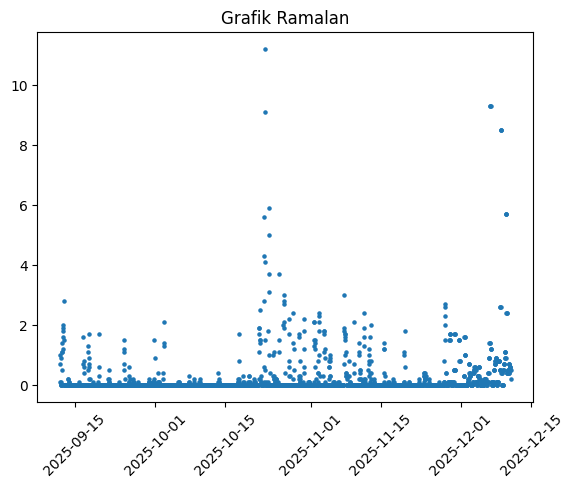

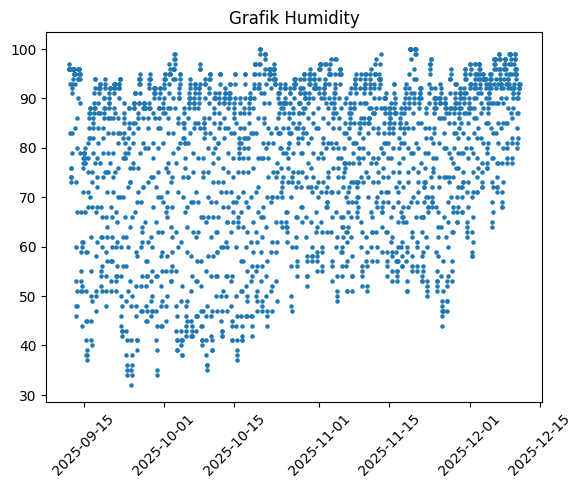

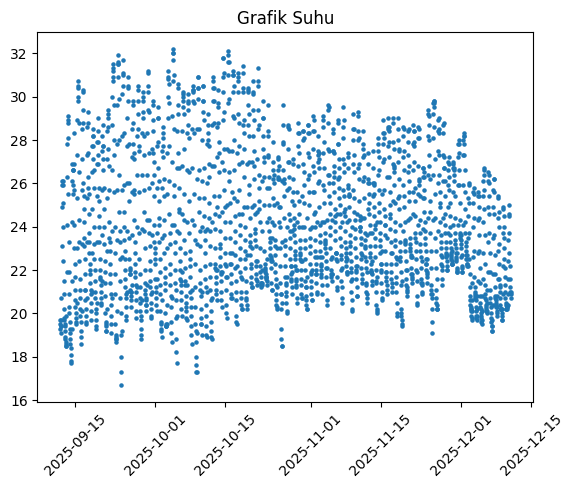

['date', 'precipitation_probability', 'precipitation', 'temperature', 'humidity', 'cloud_cover']


In [18]:
df = pd.read_csv("weather_hourly.csv")

df["date"] = pd.to_datetime(df["date"])

plt.figure()
plt.scatter(df["date"], df["precipitation"], s=5)
plt.title("Grafik Ramalan")
plt.xticks(rotation=45)

plt.figure()
plt.scatter(df["date"], df["humidity"], s=5)
plt.title("Grafik Humidity")
plt.xticks(rotation=45)

plt.figure()
plt.scatter(df["date"], df["temperature"], s=5)
plt.title("Grafik Suhu")
plt.xticks(rotation=45)

plt.show()

print(df.columns.tolist())


In [19]:
df = df.drop(['date', 'precipitation_probability', 'cloud_cover'], axis=1)

kondisi = [
    (df['humidity'] > 70) & (df['precipitation'] > 0.2) & (df['temperature'] < 27),
    (df['humidity'] > 50) & (df['humidity'] < 70) & (df['precipitation'] <= 0) & (df['temperature'] < 28) & (df['temperature'] >= 25),
    (df['humidity'] < 50) & (df['precipitation'] <= 0) & (df['temperature'] > 27)
]

label = [
    "Tidak Disiram",
    "Disiram Normal",
    "Disiram Banyak"
]

df['label'] = np.select(kondisi, label, default="Disiram sedikit")
df.to_csv("DataFinalv1.csv", index=False)

